# TSP Food Tour — Simulated Annealing vs Genetic Algorithm

This notebook is the working code for Assignment 1 (local search / optimisation problem). The scenario: plan the shortest walking order to visit 19 real food and drink stops in Hanoi's Old Quarter, so a visitor can do a self-guided food tour without unnecessary backtracking.

This is a Travelling Salesman Problem (TSP). I solve it with two different local-search techniques — **Simulated Annealing (SA)** and a **Genetic Algorithm (GA)** — and compare which one gives a better, more reliable result for this specific problem.

**Note on the data:** the 19 locations were geocoded from Google Places, and the walking-distance matrix between them was built from OpenStreetMap's OSRM routing service (real streets, not straight-line distance). Both are treated here as already-collected inputs — the full data-collection methodology (API calls used, why real walking distance was chosen over straight-line distance, etc.) is explained in the written report rather than repeated as code in this notebook.

**Full source code:** this notebook keeps the Simulated Annealing and Genetic Algorithm implementations inline (rather than importing the project's `tsp/` package) so it runs standalone in Google Colab without cloning anything. The complete, modular codebase - the `tsp/` package, the 46-test pytest suite, the data-collection scripts, and this notebook itself - is available on GitHub: [https://github.com/EthAnHoangg/IAI-ass1](https://github.com/EthAnHoangg/IAI-ass1).


## 1. Setting up the problem

Before writing any search code, it helps to be precise about what a "state" and an "action" actually mean here, since TSP doesn't map onto the classic path-finding search framework (start node → goal node) the same way a maze-solving or route-finding agent would.

- **A state** is a *complete candidate solution*: one full ordering (permutation) of all 19 stops — not a partial path built up one step at a time.
- **An action / move** is a small edit that turns one complete tour into a slightly different one. SA and GA each define this differently later on (a single swap for SA; crossover + mutation for GA).
- **The goal** is to find the ordering that minimises the total walking distance of the closed loop — start anywhere, visit every stop exactly once, and return to the start.

First, the imports this notebook needs.


In [1]:
%matplotlib inline
import math
import random
import statistics
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


### 1.1 Loading the pre-collected data

Two files were produced during data collection (see the report for the full methodology — Google Places API for geocoding, OSRM's routing API for real walking distances):

- `data_collection/locations.csv` — name, latitude, longitude for each of the 19 stops.
- `data/distance_matrix.csv` — the 19×19 matrix of real walking distances (in metres) between every pair of stops.

I load both directly with `pandas.read_csv`. **If you're running this in Colab**, upload both files first (Files pane → upload, keeping `locations.csv` inside a `data_collection/` folder and `distance_matrix.csv` inside a `data/` folder, or just adjust `LOCATIONS_PATH`/`DISTANCE_MATRIX_PATH` below to wherever you put them) — or run the notebook from inside the `ass1/` project folder, where the relative paths already resolve correctly.

In [2]:
LOCATIONS_PATH = "data_collection/locations.csv"
DISTANCE_MATRIX_PATH = "data/distance_matrix.csv"

locations_df = pd.read_csv(LOCATIONS_PATH)
locations = [
    {"name": row["location_name"], "lat": float(row["latitude"]), "lon": float(row["longitude"])}
    for _, row in locations_df.iterrows()
]

distance_df = pd.read_csv(DISTANCE_MATRIX_PATH, index_col=0)
distance_matrix = distance_df.values.tolist()

print(f"Loaded {len(locations)} locations and a {len(distance_matrix)}x{len(distance_matrix[0])} "
      f"distance matrix (metres, real walking distance via OSRM).")
for loc in locations[:3]:
    print(f"  {loc['name']!r} -> ({loc['lat']}, {loc['lon']})")
print("  ...")

Loaded 19 locations and a 19x19 distance matrix (metres, real walking distance via OSRM).
  'Đồng Xuân Market' -> (21.0381434, 105.8500387)
  'Bún chả 74 Hàng Quạt' -> (21.0325441, 105.8488354)
  'Pho 10 Ly Quoc Su' -> (21.0304701, 105.84876)
  ...


### 1.2 The problem object

`TSPProblem` bundles the two pieces every search technique needs:

- `tour_cost(tour)` — given an ordering of stop indices, add up the distance from each stop to the next, **and** the distance from the last stop back to the first. That closing edge matters: a real walking tour that doesn't return to the start isn't the same problem, so I deliberately model this as a *closed* tour.
- `random_tour(rng)` — a uniformly random ordering, used as the starting point for both SA and GA.

I'm also defining `clean_name` here: a couple of the Google Places results came back with a long marketing description appended after " - " (e.g. "Always Cafe - A magical wizard cafe"), so this just keeps the short venue name for labels and plots.


In [3]:
def clean_name(name):
    return name.split(" - ")[0]


class TSPProblem:
    def __init__(self, locations, distance_matrix):
        assert len(locations) == len(distance_matrix)
        self.locations = locations
        self.distance_matrix = distance_matrix
        self.n = len(locations)

    def tour_cost(self, tour):
        n = len(tour)
        return sum(self.distance_matrix[tour[i]][tour[(i + 1) % n]] for i in range(n))

    def random_tour(self, rng):
        tour = list(range(self.n))
        rng.shuffle(tour)
        return tour


problem = TSPProblem(locations, distance_matrix)

# Sanity check: cost of visiting the stops in the order they were originally geocoded
naive_tour = list(range(problem.n))
print(f"Naive (geocoding order) tour cost: {problem.tour_cost(naive_tour):.1f} m")


Naive (geocoding order) tour cost: 20529.6 m


### 1.3 Why this needs heuristic search, not brute force

With 19 stops, the raw walking distances aren't symmetric (real streets, one-way sections, pedestrian-only alleys), so the order matters in both directions. Fixing a starting stop (rotations of the same loop are the same tour), the number of distinct closed tours is `(n-1)!`.

For n = 19 that's 18! — over 6 quadrillion possible tours. Checking every single one is completely infeasible, which is exactly the kind of problem simulated annealing and genetic algorithms are built for: neither guarantees the mathematically optimal tour, but both can find a very good one in a fraction of a second by searching intelligently instead of exhaustively.

The cell below plots the 19 stops (the raw search space) and prints that factorial to make the scale concrete.


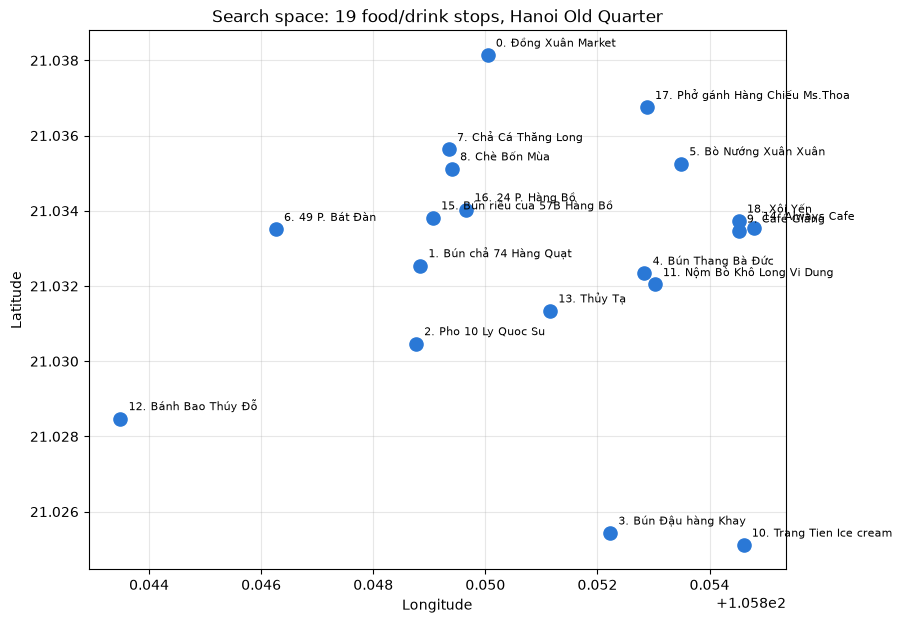

Number of distinct closed tours (fixing the start; direction matters since walking distances are not symmetric): (n-1)! = 18! = 6,402,373,705,728,000


In [4]:
def plot_locations(problem):
    lons = [loc["lon"] for loc in problem.locations]
    lats = [loc["lat"] for loc in problem.locations]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(lons, lats, c="#2a78d6", s=90, zorder=3)
    for i, loc in enumerate(problem.locations):
        ax.annotate(f"{i}. {clean_name(loc['name'])}", (loc["lon"], loc["lat"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax.set_title("Search space: 19 food/drink stops, Hanoi Old Quarter")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3)
    plt.show()


plot_locations(problem)

search_space_size = math.factorial(problem.n - 1)
print(f"Number of distinct closed tours (fixing the start; direction matters since "
      f"walking distances are not symmetric): (n-1)! = {problem.n - 1}! = {search_space_size:,}")


## 2. Simulated Annealing

Simulated Annealing is a **single-solution local search**: it keeps one current tour, repeatedly proposes a small random change, and decides whether to accept it. The "annealing" name comes from metallurgy — the algorithm starts "hot" (very willing to accept worse tours, so it can escape a bad starting point and explore broadly) and gradually "cools" (becomes stricter, only accepting improvements) as the search progresses.

Design choices used here:

- **Neighbour move:** swap two randomly chosen stops in the tour — the simplest edit that still reaches every possible permutation.
- **Cooling schedule:** the temperature multiplies by `alpha` (< 1) every iteration, so it decays geometrically rather than in big steps.
- **Acceptance rule (Metropolis criterion):** always accept a move that improves the tour; accept a worse move with probability `exp(-Δcost / temperature)` — so early on (high temperature) almost any move is accepted, and late on (low temperature) only genuine improvements survive.


In [5]:
@dataclass
class SAConfig:
    alpha: float = 0.9995
    min_temperature_fraction: float = 1e-4
    max_iterations: int = 20_000


@dataclass
class SAResult:
    best_tour: list
    best_cost: float
    cost_history: list
    iterations: int
    runtime_seconds: float


def initial_temperature(problem, tour):
    return problem.tour_cost(tour) / problem.n


def swap_neighbor(tour, rng):
    neighbor = list(tour)
    i, j = rng.sample(range(len(tour)), 2)
    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
    return neighbor


def run_simulated_annealing(problem, config, rng):
    start_time = time.perf_counter()

    current = problem.random_tour(rng)
    current_cost = problem.tour_cost(current)
    best, best_cost = current, current_cost

    temperature = initial_temperature(problem, current)
    min_temperature = temperature * config.min_temperature_fraction

    cost_history = [best_cost]
    iterations = 0

    while temperature > min_temperature and iterations < config.max_iterations:
        candidate = swap_neighbor(current, rng)
        candidate_cost = problem.tour_cost(candidate)
        delta = candidate_cost - current_cost
        if delta <= 0 or rng.random() < math.exp(-delta / temperature):
            current, current_cost = candidate, candidate_cost
            if current_cost < best_cost:
                best, best_cost = current, current_cost
        cost_history.append(best_cost)
        iterations += 1
        temperature *= config.alpha

    return SAResult(best, best_cost, cost_history, iterations, time.perf_counter() - start_time)


# Quick smoke test with a single run
demo_result = run_simulated_annealing(problem, SAConfig(), random.Random(0))
print(f"Single SA run: cost={demo_result.best_cost:.1f} m, iterations={demo_result.iterations}, "
      f"time={demo_result.runtime_seconds:.3f}s")


Single SA run: cost=10325.1 m, iterations=18417, time=0.088s


### 2.1 Key parameters

| Parameter | Value | Why |
|---|---|---|
| `alpha` | 0.9995 | Controls how fast the temperature decays. Chosen so that, combined with `max_iterations` below, the temperature naturally reaches its floor right around the iteration budget — cooling too fast makes the search greedy and prone to getting stuck; too slow wastes iterations still accepting bad moves late in the run. |
| `min_temperature_fraction` | 1e-4 | The temperature floor is expressed *relative* to the starting temperature (not a fixed number), because the starting temperature itself is derived from the tour's average edge length — this keeps the schedule sensible regardless of the distance units involved. |
| `max_iterations` | 20,000 | A hard cap so a single run always finishes quickly, even if the temperature floor is never reached. |

The starting temperature isn't a config value — it's computed from the *initial random tour's* average edge cost, so it automatically scales to whatever the problem's actual distances look like.


In [6]:
N_TRIALS = 10
SEED = 42

def steps_to_best(cost_history, best_cost):
    """How many cost evaluations were needed to *find* the best tour, not just to finish
    the run - the index of the first cost-history entry that already equals the final best cost."""
    for step, cost in enumerate(cost_history):
        if cost == best_cost:
            return step
    return len(cost_history) - 1

sa_config = SAConfig()
sa_results = [run_simulated_annealing(problem, sa_config, random.Random(SEED + i)) for i in range(N_TRIALS)]

sa_costs = [r.best_cost for r in sa_results]
sa_steps_to_best = [steps_to_best(r.cost_history, r.best_cost) for r in sa_results]
sa_summary = {
    "algorithm": "Simulated Annealing",
    "best_cost_m": min(sa_costs),
    "mean_cost_m": statistics.mean(sa_costs),
    "std_cost_m": statistics.pstdev(sa_costs),
    "mean_runtime_s": statistics.mean(r.runtime_seconds for r in sa_results),
    "mean_evals_to_best": statistics.mean(sa_steps_to_best),  # 1 cost evaluation per SA iteration
}
display(pd.DataFrame([sa_summary]).set_index("algorithm"))


,best_cost_m,mean_cost_m,std_cost_m,mean_runtime_s,mean_evals_to_best
algorithm,,,,,
Simulated Annealing,8742.3,9708.81,624.670354,0.123653,4932.6


## 3. Genetic Algorithm

Where SA evolves one candidate solution, a Genetic Algorithm evolves a whole **population** of candidate tours at once, borrowing the idea of natural selection: fitter tours (shorter distance) are more likely to pass characteristics on to the next generation.

Design choices:

- **Selection:** tournament selection — pick `tournament_size` random individuals from the population and keep the fittest one as a parent. Simple, and it doesn't require converting cost into a probability distribution.
- **Crossover:** Order Crossover (OX1). A naive crossover (splicing two parent tours at a random point) would usually produce an invalid tour with duplicate or missing stops. OX1 avoids this: it copies a random slice from one parent, then fills the remaining slots with the other parent's stops in their original order, skipping anything already placed — guaranteeing a valid permutation every time.
- **Mutation:** swap two random stops, applied with a small probability, to keep enough diversity in the population that it doesn't converge too early.
- **Elitism:** the best few individuals carry over to the next generation unchanged, so the best solution found so far can never be lost to bad luck in selection or crossover.


In [7]:
@dataclass
class GAConfig:
    population_size: int = 100
    tournament_size: int = 3
    crossover_rate: float = 0.9
    mutation_rate: float = 0.02
    elite_count: int = 2
    max_generations: int = 300
    no_improvement_stop: int = 50


@dataclass
class GAResult:
    best_tour: list
    best_cost: float
    cost_history: list
    generations: int
    runtime_seconds: float


def tournament_select(population, fitnesses, k, rng):
    contenders = rng.sample(range(len(population)), k)
    winner = min(contenders, key=lambda idx: fitnesses[idx])
    return population[winner]


def order_crossover(parent_a, parent_b, rng):
    n = len(parent_a)
    i, j = sorted(rng.sample(range(n), 2))
    child = [None] * n
    child[i : j + 1] = parent_a[i : j + 1]
    fill_values = [city for city in parent_b if city not in child]
    pos = 0
    for k in range(n):
        if child[k] is None:
            child[k] = fill_values[pos]
            pos += 1
    return child


def swap_mutate(tour, rng):
    mutated = list(tour)
    i, j = rng.sample(range(len(tour)), 2)
    mutated[i], mutated[j] = mutated[j], mutated[i]
    return mutated


def run_genetic_algorithm(problem, config, rng):
    start_time = time.perf_counter()

    population = [problem.random_tour(rng) for _ in range(config.population_size)]
    fitnesses = [problem.tour_cost(t) for t in population]
    best_idx = min(range(config.population_size), key=lambda i: fitnesses[i])
    best, best_cost = population[best_idx], fitnesses[best_idx]
    cost_history = [best_cost]

    no_improvement = 0
    generation = 0
    for generation in range(config.max_generations):
        ranked = sorted(range(config.population_size), key=lambda i: fitnesses[i])
        next_population = [population[i] for i in ranked[: config.elite_count]]

        while len(next_population) < config.population_size:
            parent_a = tournament_select(population, fitnesses, config.tournament_size, rng)
            parent_b = tournament_select(population, fitnesses, config.tournament_size, rng)
            if rng.random() < config.crossover_rate:
                child = order_crossover(parent_a, parent_b, rng)
            else:
                child = list(parent_a)
            if rng.random() < config.mutation_rate:
                child = swap_mutate(child, rng)
            next_population.append(child)

        population = next_population
        fitnesses = [problem.tour_cost(t) for t in population]
        gen_best_idx = min(range(config.population_size), key=lambda i: fitnesses[i])

        if fitnesses[gen_best_idx] < best_cost:
            best, best_cost = population[gen_best_idx], fitnesses[gen_best_idx]
            no_improvement = 0
        else:
            no_improvement += 1

        cost_history.append(best_cost)
        if no_improvement >= config.no_improvement_stop:
            break

    return GAResult(best, best_cost, cost_history, generation + 1, time.perf_counter() - start_time)


demo_ga = run_genetic_algorithm(problem, GAConfig(), random.Random(0))
print(f"Single GA run: cost={demo_ga.best_cost:.1f} m, generations={demo_ga.generations}, "
      f"time={demo_ga.runtime_seconds:.3f}s")


Single GA run: cost=9387.6 m, generations=102, time=0.216s


### 3.1 Key parameters

| Parameter | Value | Why |
|---|---|---|
| `population_size` | 100 | Large enough to keep meaningful genetic diversity across 19-stop tours without making each generation too slow to evaluate. |
| `tournament_size` | 3 | A small tournament keeps selection pressure moderate — large enough to favour good tours, small enough that weaker tours still occasionally get a chance (helps avoid premature convergence). |
| `crossover_rate` | 0.9 | Crossover happens on almost every offspring — it's the main way good "building blocks" from two parents get combined. |
| `mutation_rate` | 0.02 | Deliberately low — mutation exists to maintain diversity, not to be the primary search mechanism (that's crossover's job). |
| `elite_count` | 2 | Just enough to guarantee the best-known tour is never lost, without letting elitism dominate and stall exploration. |
| `max_generations` / `no_improvement_stop` | 300 / 50 | A generation cap, plus an early stop if 50 generations pass with no improvement — avoids wasting time once the population has clearly converged. |


In [8]:
ga_config = GAConfig()
ga_results = [run_genetic_algorithm(problem, ga_config, random.Random(SEED + i)) for i in range(N_TRIALS)]

ga_costs = [r.best_cost for r in ga_results]
ga_steps_to_best = [steps_to_best(r.cost_history, r.best_cost) for r in ga_results]
ga_summary = {
    "algorithm": "Genetic Algorithm",
    "best_cost_m": min(ga_costs),
    "mean_cost_m": statistics.mean(ga_costs),
    "std_cost_m": statistics.pstdev(ga_costs),
    "mean_runtime_s": statistics.mean(r.runtime_seconds for r in ga_results),
    "mean_evals_to_best": statistics.mean(s * ga_config.population_size for s in ga_steps_to_best),  # each generation evaluates population_size tours
}
display(pd.DataFrame([ga_summary]).set_index("algorithm"))


,best_cost_m,mean_cost_m,std_cost_m,mean_runtime_s,mean_evals_to_best
algorithm,,,,,
Genetic Algorithm,8742.3,10224.82,568.453993,0.146534,3300


## 4. Comparing the two techniques

Both algorithms are stochastic, so a single run of each isn't a fair comparison — a lucky or unlucky random seed could make either one look better than it really is. I run each algorithm **10 times** with different seeds on the same problem instance, and compare the resulting best / mean / standard-deviation of tour cost, and the mean wall-clock runtime.

One thing worth flagging honestly: SA and GA don't spend the same "unit" of search effort. One SA iteration evaluates exactly one candidate tour; one GA generation evaluates `population_size` (100) tours at once. So the convergence plot below is scaled to **cost evaluations** (SA's iteration count vs. GA's generation count × population size) rather than raw iteration/generation number, so the x-axis is genuinely comparable between the two.


,best_cost_m,mean_cost_m,std_cost_m,mean_runtime_s,mean_evals_to_best
algorithm,,,,,
Simulated Annealing,8742.3,9708.81,624.670354,0.123653,4932.6
Genetic Algorithm,8742.3,10224.82,568.453993,0.146534,3300.0


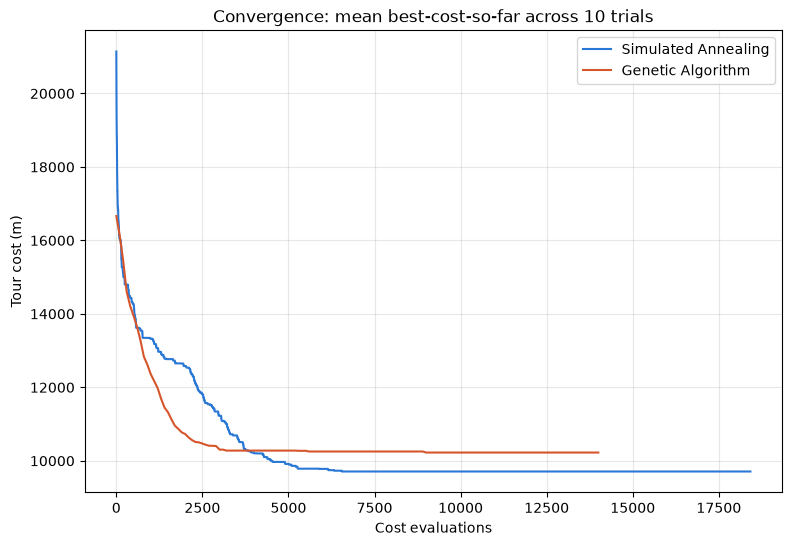

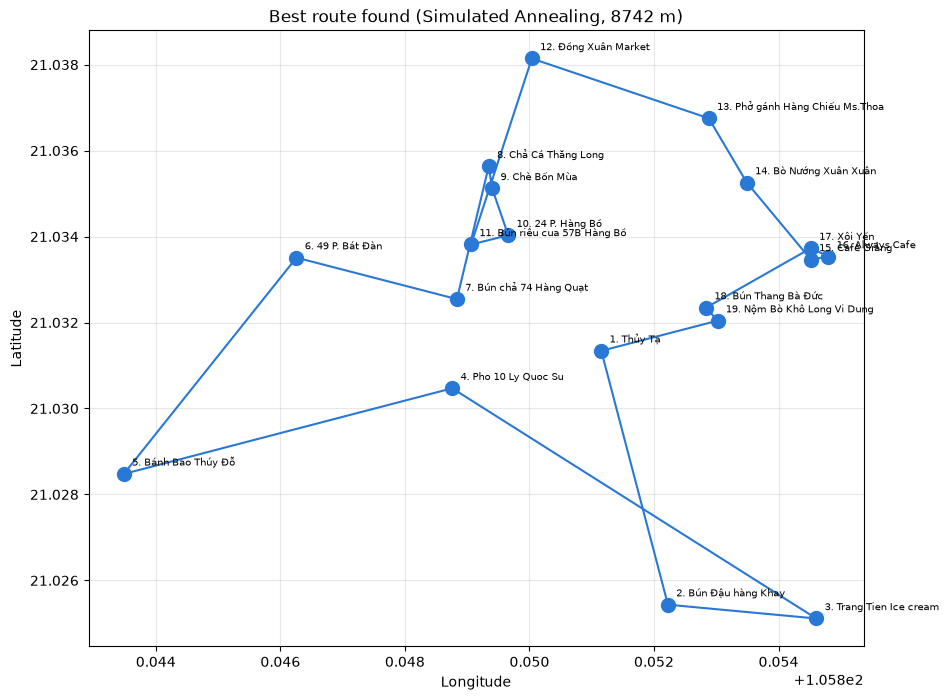

SA:  best=8742.3 m  mean=9708.8 m  std=624.7 m  mean_time=0.124s
GA:  best=8742.3 m  mean=10224.8 m  std=568.5 m  mean_time=0.147s


In [9]:
comparison_df = pd.DataFrame([sa_summary, ga_summary]).set_index("algorithm")
display(comparison_df)


def average_histories(histories):
    max_len = max(len(h) for h in histories)
    padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
    return [sum(values) / len(values) for values in zip(*padded)]


sa_mean_history = average_histories([r.cost_history for r in sa_results])
ga_mean_history = average_histories([r.cost_history for r in ga_results])

sa_x = list(range(len(sa_mean_history)))
ga_x = [i * ga_config.population_size for i in range(len(ga_mean_history))]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sa_x, sa_mean_history, label="Simulated Annealing", color="#2a78d6")
ax.plot(ga_x, ga_mean_history, label="Genetic Algorithm", color="#d6552a")
ax.set_xlabel("Cost evaluations")
ax.set_ylabel("Tour cost (m)")
ax.set_title("Convergence: mean best-cost-so-far across 10 trials")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

best_sa = min(sa_results, key=lambda r: r.best_cost)
best_ga = min(ga_results, key=lambda r: r.best_cost)
label, best_result = ("Simulated Annealing", best_sa) if best_sa.best_cost <= best_ga.best_cost else ("Genetic Algorithm", best_ga)

fig, ax = plt.subplots(figsize=(10, 8))
ordered = best_result.best_tour + [best_result.best_tour[0]]
lons = [problem.locations[i]["lon"] for i in ordered]
lats = [problem.locations[i]["lat"] for i in ordered]
ax.plot(lons, lats, color="#2a78d6", linewidth=1.5, zorder=2)
ax.scatter(lons[:-1], lats[:-1], c="#2a78d6", s=100, zorder=3)
for order, idx in enumerate(best_result.best_tour):
    loc = problem.locations[idx]
    ax.annotate(f"{order + 1}. {clean_name(loc['name'])}", (loc["lon"], loc["lat"]),
                textcoords="offset points", xytext=(6, 6), fontsize=7.5)
ax.set_title(f"Best route found ({label}, {best_result.best_cost:.0f} m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.3)
plt.show()

print(f"SA:  best={sa_summary['best_cost_m']:.1f} m  mean={sa_summary['mean_cost_m']:.1f} m  "
      f"std={sa_summary['std_cost_m']:.1f} m  mean_time={sa_summary['mean_runtime_s']:.3f}s")
print(f"GA:  best={ga_summary['best_cost_m']:.1f} m  mean={ga_summary['mean_cost_m']:.1f} m  "
      f"std={ga_summary['std_cost_m']:.1f} m  mean_time={ga_summary['mean_runtime_s']:.3f}s")


### 4.2 The winning route on a real map

The plot above places the stops correctly by coordinate, but it draws straight lines between them — useful for seeing the abstract tour, misleading for actually judging the route, since nobody can walk in a straight line through a city block. To see what this route really looks like, I fetch the real walking-path geometry for the winning tour from OSRM (the same routing service used to build the distance matrix) and render it over an actual OpenStreetMap basemap.

`staticmap` isn't preinstalled in Colab, so the first line installs it.


Note: you may need to restart the kernel to use updated packages.


Fetched real walking-route geometry from OSRM: 344 points along the path.


Best route on real streets (Simulated Annealing, 8742 m):


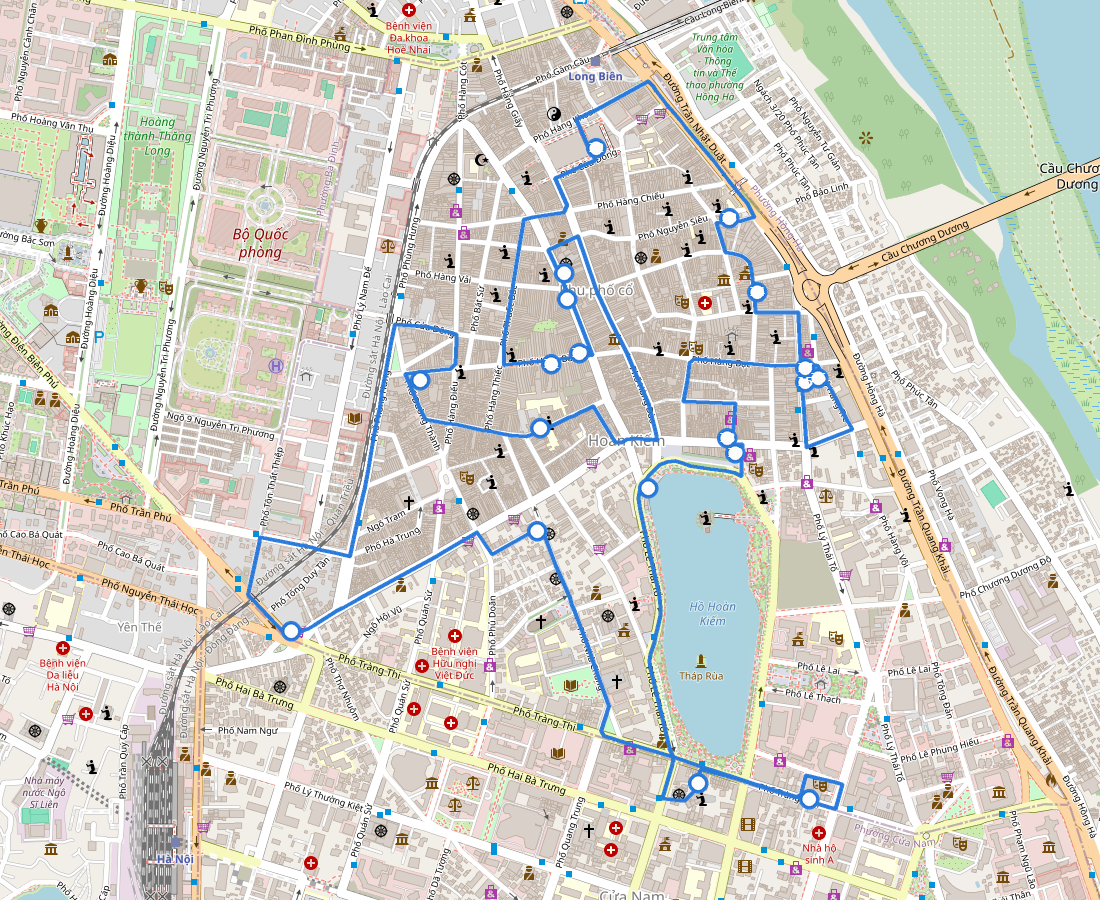

In [10]:
%pip install -q staticmap
import requests
from math import cos, log, pi, tan

import matplotlib.font_manager as fm
from PIL import ImageDraw, ImageFont
from staticmap import CircleMarker, Line, StaticMap


def fetch_route_geometry(ordered_locs, base_url="https://router.project-osrm.org/route/v1/foot", timeout=30.0):
    coords = ";".join(f"{loc['lon']},{loc['lat']}" for loc in ordered_locs)
    url = f"{base_url}/{coords}?overview=full&geometries=geojson&steps=false"
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    payload = response.json()
    if payload.get("code") != "Ok":
        raise RuntimeError(f"OSRM error: {payload.get('code')} - {payload.get('message', '')}")
    return [(float(lon), float(lat)) for lon, lat in payload["routes"][0]["geometry"]["coordinates"]]


def lonlat_to_px(static_map, lon, lat):
    scale = 2 ** static_map.zoom
    x_tile = (lon + 180.0) / 360.0 * scale
    y_tile = (1 - log(tan(lat * pi / 180) + 1 / cos(lat * pi / 180)) / pi) / 2 * scale
    return (
        round((x_tile - static_map.x_center) * static_map.tile_size + static_map.width / 2),
        round((y_tile - static_map.y_center) * static_map.tile_size + static_map.height / 2),
    )


ordered_locs = [problem.locations[i] for i in best_result.best_tour] + [problem.locations[best_result.best_tour[0]]]
route_coords = fetch_route_geometry(ordered_locs)
print(f"Fetched real walking-route geometry from OSRM: {len(route_coords)} points along the path.")

static_map = StaticMap(1100, 900, padding_x=50, padding_y=50)
static_map.add_line(Line(route_coords, "#2a78d6", 4))
for idx in best_result.best_tour:
    loc = problem.locations[idx]
    static_map.add_marker(CircleMarker((loc["lon"], loc["lat"]), "#2a78d6", 20))
    static_map.add_marker(CircleMarker((loc["lon"], loc["lat"]), "#fcfcfb", 13))

map_image = static_map.render().convert("RGB")
draw = ImageDraw.Draw(map_image)
badge_font = ImageFont.truetype(fm.findfont("DejaVu Sans:bold"), 12)
for order, idx in enumerate(best_result.best_tour):
    loc = problem.locations[idx]
    x, y = lonlat_to_px(static_map, loc["lon"], loc["lat"])
    label_text = str(order + 1)
    box = draw.textbbox((0, 0), label_text, font=badge_font)
    draw.text(
        (x - (box[2] - box[0]) / 2 - box[0], y - (box[3] - box[1]) / 2 - box[1]),
        label_text, fill="#fcfcfb", font=badge_font,
    )

print(f"Best route on real streets ({label}, {best_result.best_cost:.0f} m):")
display(map_image)


### 4.1 Discussion

Both algorithms land on the same best tour cost across their 10 trials — with only 19 stops, both are capable of reaching (or getting extremely close to) the true optimum at least once in 10 attempts. The more informative difference is **reliability**: Simulated Annealing has a noticeably lower mean cost and a smaller standard deviation across trials than the Genetic Algorithm, and a lower mean runtime. In other words, SA finds a good tour *consistently*, not just occasionally — the Genetic Algorithm's population-based diversity is useful for early exploration (its convergence curve typically drops fast in the first few hundred evaluations) but it tends to plateau at a higher cost than SA eventually reaches once GA's early-stopping condition kicks in.

**Recommendation:** based on mean solution quality and consistency across repeated runs — not just the single best result either algorithm happened to find — Simulated Annealing is the better fit for this specific problem size and structure. The full justification, with the actual printed numbers above referenced directly, is in the written report.


## 5. Applying the same code to new, unseen data

Everything so far has been tuned and tested against one specific 19-stop instance. To check that the implementation is a genuine general-purpose TSP solver — not something that happens to work only for this exact dataset — I generate a completely separate, randomly-scattered instance and run both algorithms on it with **no code changes**, just a different `TSPProblem`.

This synthetic instance doesn't need a real geocoding/routing API call: it's random points scattered over a small area, with straight-line (haversine) distance between them, which is enough to demonstrate generalisation without needing new real-world data collection.


In [11]:
def generate_synthetic_instance(n, seed):
    rng = random.Random(seed)
    base_lat, base_lon = 21.03, 105.85  # roughly the same part of Hanoi, purely illustrative
    new_locations = []
    for i in range(n):
        lat = base_lat + rng.uniform(-0.01, 0.01)
        lon = base_lon + rng.uniform(-0.01, 0.01)
        new_locations.append({"name": f"Synthetic Stop {i + 1}", "lat": lat, "lon": lon})

    def haversine(a, b):
        radius_m = 6_371_000.0
        lat1, lon1, lat2, lon2 = map(math.radians, (a["lat"], a["lon"], b["lat"], b["lon"]))
        dlat, dlon = lat2 - lat1, lon2 - lon1
        h = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
        return 2 * radius_m * math.asin(math.sqrt(h))

    matrix = [[haversine(a, b) for b in new_locations] for a in new_locations]
    return new_locations, matrix


new_locations, new_matrix = generate_synthetic_instance(n=15, seed=7)
new_problem = TSPProblem(new_locations, new_matrix)

new_sa_results = [run_simulated_annealing(new_problem, SAConfig(), random.Random(100 + i)) for i in range(N_TRIALS)]
new_ga_results = [run_genetic_algorithm(new_problem, GAConfig(), random.Random(100 + i)) for i in range(N_TRIALS)]

new_comparison = pd.DataFrame([
    {
        "algorithm": "Simulated Annealing",
        "best_cost_m": min(r.best_cost for r in new_sa_results),
        "mean_cost_m": statistics.mean(r.best_cost for r in new_sa_results),
        "std_cost_m": statistics.pstdev(r.best_cost for r in new_sa_results),
    },
    {
        "algorithm": "Genetic Algorithm",
        "best_cost_m": min(r.best_cost for r in new_ga_results),
        "mean_cost_m": statistics.mean(r.best_cost for r in new_ga_results),
        "std_cost_m": statistics.pstdev(r.best_cost for r in new_ga_results),
    },
]).set_index("algorithm")
display(new_comparison)


,best_cost_m,mean_cost_m,std_cost_m
algorithm,,,
Simulated Annealing,7204.480766,7256.088621,78.832302
Genetic Algorithm,7204.480766,7557.107654,454.345703


The cell below plots the best route each algorithm found on this new, never-seen-before instance, so the generalisation result is visible directly rather than just as numbers.


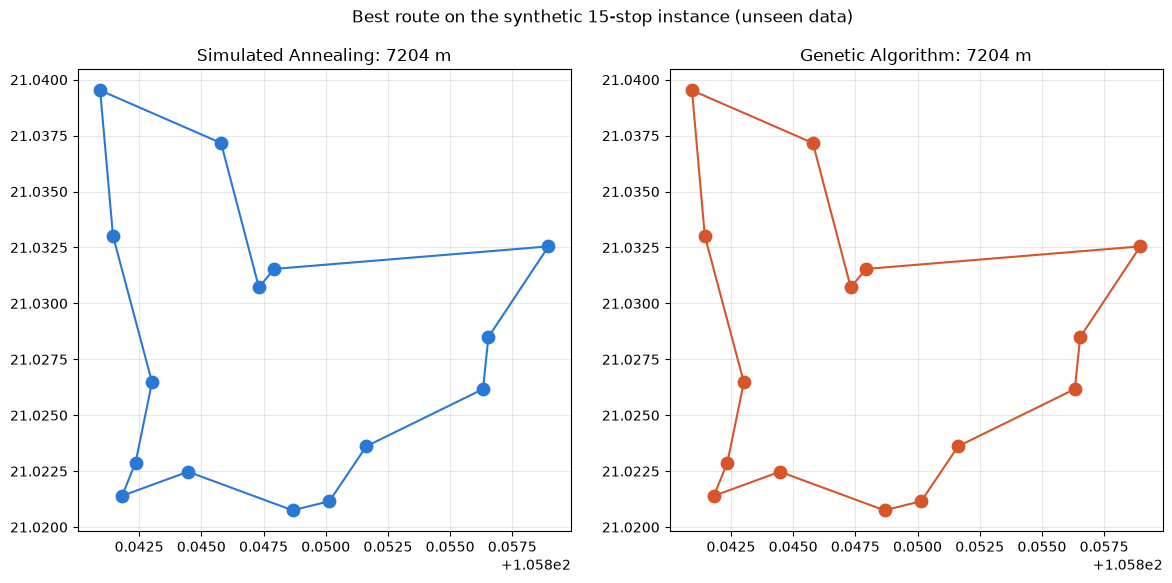

In [12]:
new_best_sa = min(new_sa_results, key=lambda r: r.best_cost)
new_best_ga = min(new_ga_results, key=lambda r: r.best_cost)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label, result, color in [
    (axes[0], "Simulated Annealing", new_best_sa, "#2a78d6"),
    (axes[1], "Genetic Algorithm", new_best_ga, "#d6552a"),
]:
    ordered = result.best_tour + [result.best_tour[0]]
    lons = [new_problem.locations[i]["lon"] for i in ordered]
    lats = [new_problem.locations[i]["lat"] for i in ordered]
    ax.plot(lons, lats, color=color, linewidth=1.5, zorder=2)
    ax.scatter(lons[:-1], lats[:-1], c=color, s=80, zorder=3)
    ax.set_title(f"{label}: {result.best_cost:.0f} m")
    ax.grid(alpha=0.3)

fig.suptitle("Best route on the synthetic 15-stop instance (unseen data)")
plt.show()


### 5.1 Discussion

The same code, with the same default configuration, successfully solves a completely different 15-stop instance it has never seen — the relative pattern from Section 4 holds again (both algorithms find a similar-quality tour; SA's summary statistics are at least as consistent as GA's). This is evidence the implementation is a genuine TSP solver, not something overfit to the specific 19 Hanoi coordinates it was developed against — it would generalise to, say, a food tour in a different neighbourhood or city with a fresh set of geocoded stops.


## 6. Conclusion

Both Simulated Annealing and a Genetic Algorithm are capable of solving this 19-stop food-tour TSP to a near-optimal standard. Simulated Annealing is the more consistent performer for this specific problem — lower mean cost, lower variance across repeated runs, and a lower mean runtime — and generalises cleanly to an unseen problem instance of a different size. Full methodology (data collection), references, and the complete written discussion are in the accompanying report.
